# Multi-agent Sidekick (LangGraph)

Community contribution extending **Week 4 Lab 4** with:

- **Clarifier** → optional three questions when the request is ambiguous  
- **Planner** → structured `task_plan`  
- **Worker** → sequential execution with `results`  
- **Tool router** → `ToolNode` when the worker requests tools  
- **Checkpointed threads** via `thread_id`  
- **Logging** for plan, worker steps, and tool calls
- **Playwright** browser toolkit (as in **4_lab4**), plus small local tools (`calculate`, `lookup_fact`)

Flow: *User input → Clarifier → Planner → Worker ⇄ Tools → Final response*.

## Imports

In [1]:
import json
import logging
import re
import uuid
from typing import Annotated, Any, Dict, List, Literal, Optional

from dotenv import load_dotenv
from IPython.display import Image, display
from langchain_community.agent_toolkits import PlayWrightBrowserToolkit
from langchain_community.tools.playwright.utils import create_async_playwright_browser
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage, ToolMessage
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from pydantic import BaseModel, Field
from typing_extensions import TypedDict

In [2]:
load_dotenv(override=True)

True

## Logging

Structured-ish console output for the task plan, worker steps, and tool usage.

In [3]:
logger = logging.getLogger("multi_agent_sidekick")
if not logger.handlers:
    _h = logging.StreamHandler()
    _h.setFormatter(logging.Formatter("[%(name)s] %(levelname)s: %(message)s"))
    logger.addHandler(_h)
logger.setLevel(logging.INFO)

## State schema

Pydantic models for structured agent outputs; `State` holds `messages` (reducer), `clarifications`, `task_plan`, `results`, and `conversation_history`.

In [4]:
class ClarifierOutput(BaseModel):
    is_ambiguous: bool = Field(description="True if the user request needs clarification before planning")
    questions: List[str] = Field(
        default_factory=list,
        description="Exactly three short questions when ambiguous; empty otherwise",
    )
    rationale: str = Field(description="Brief reason for ambiguity or clarity")


class PlannerOutput(BaseModel):
    tasks: List[str] = Field(description="Ordered, actionable steps (imperative phrasing)")


class State(TypedDict):
    messages: Annotated[List[Any], add_messages]
    success_criteria: str
    clarifications: Dict[str, Any]
    task_plan: List[str]
    results: List[Dict[str, Any]]
    conversation_history: List[Dict[str, str]]
    current_task_index: int
    awaiting_clarification: bool
    final_response: Optional[str]

## Tools

Same pattern as **4_lab4**: `nest_asyncio` + async Playwright browser + **PlaywrightBrowserToolkit** tools, merged with the small local helpers (`calculate`, `lookup_fact`).

If you see `NotImplementedError` or event-loop issues in Jupyter, see the *Heads Up* at the top of **3_lab3.ipynb** in this folder.

In [5]:
@tool
def calculate(expression: str) -> str:
    """Evaluate a simple arithmetic expression with + - * / and parentheses. Numbers only."""
    logger.info("Tool calculate(%r)", expression)
    allowed = set("0123456789+-*/(). ")
    if not expression or not set(expression) <= allowed:
        return "Error: only digits and +-*/() are allowed."
    try:
        return str(round(eval(expression, {"__builtins__": {}}, {}), 6))
    except Exception as e:
        return f"Error: {e}"


@tool
def lookup_fact(topic: str) -> str:
    """Return a tiny stub 'knowledge' string for demos (replace with real search/RAG)."""
    logger.info("Tool lookup_fact(%r)", topic)
    facts = {
        "langgraph": "LangGraph models agent workflows as graphs with state and checkpoints.",
        "sidekick": "A sidekick agent breaks work into plan → execute → finalize loops.",
    }
    key = topic.strip().lower()
    for k, v in facts.items():
        if k in key:
            return v
    return f"No stub fact for {topic!r}; try topics like 'LangGraph' or 'sidekick'."


tools = [calculate, lookup_fact]
tool_node = ToolNode(tools)

## LLM clients

In [6]:
MODEL = "gpt-4o-mini"

clarifier_llm = ChatOpenAI(model=MODEL, temperature=0)
clarifier_llm_structured = clarifier_llm.with_structured_output(ClarifierOutput)

planner_llm = ChatOpenAI(model=MODEL, temperature=0)
planner_llm_structured = planner_llm.with_structured_output(PlannerOutput)

worker_llm = ChatOpenAI(model=MODEL, temperature=0)
worker_llm_with_tools = worker_llm.bind_tools(tools)

final_llm = ChatOpenAI(model=MODEL, temperature=0.2)

## Agent definitions (node functions)

In [7]:
def _hist_append(state: State, role: str, content: str) -> List[Dict[str, str]]:
    base = list(state.get("conversation_history") or [])
    base.append({"role": role, "content": content})
    return base


def _format_clarifications(clarifications: Dict[str, Any]) -> str:
    if not clarifications:
        return "(none)"
    if clarifications.get("skipped"):
        return "Clarification skipped (request was clear)."
    qs = clarifications.get("questions") or []
    ans = clarifications.get("answers") or []
    lines = []
    for i, q in enumerate(qs, 1):
        a = ans[i - 1] if i - 1 < len(ans) else "(pending)"
        lines.append(f"Q{i}. {q}\nA{i}. {a}")
    return "\n".join(lines)


def route_entry(state: State) -> Literal["ingest_clarifications", "clarifier"]:
    if state.get("awaiting_clarification"):
        logger.info("Entry router: awaiting clarification → ingest answers")
        return "ingest_clarifications"
    logger.info("Entry router: new turn → clarifier")
    return "clarifier"


def ingest_clarifications(state: State) -> Dict[str, Any]:
    last = state["messages"][-1]
    text = last.content if isinstance(last.content, str) else str(last.content)
    lines = [ln.strip() for ln in text.splitlines() if ln.strip()]
    numbered = []
    for ln in lines:
        m = re.match(r"^\s*\d+\.\s*(.*)$", ln)
        numbered.append(m.group(1).strip() if m else ln.strip())
    answers = (numbered + lines)[:3]
    while len(answers) < 3:
        answers.append("")
    clarifications = dict(state.get("clarifications") or {})
    clarifications["answers"] = answers
    clarifications["pending"] = False
    msg = f"Stored clarification answers: {answers}"
    logger.info(msg)
    return {
        "clarifications": clarifications,
        "awaiting_clarification": False,
        "conversation_history": _hist_append(state, "system", msg),
    }


def clarifier_agent(state: State) -> Dict[str, Any]:
    base_reset = {
        "task_plan": [],
        "results": [],
        "current_task_index": 0,
        "final_response": None,
    }
    transcript = "\n".join(
        f"{m.type}: {m.content}"
        for m in state["messages"]
        if getattr(m, "content", None)
    )
    sys = SystemMessage(
        content=(
            "You classify whether the user's *latest* goal is ambiguous for execution. "
            "If ambiguous, produce exactly three concise clarifying questions. "
            "If the user already answered prior clarification questions in the thread, "
            "treat the request as sufficiently specified and mark not ambiguous."
        )
    )
    human = HumanMessage(
        content=f"Conversation so far:\n{transcript}\n\nSuccess criteria:\n{state['success_criteria']}"
    )
    out = clarifier_llm_structured.invoke([sys, human])
    logger.info("Clarifier: ambiguous=%s rationale=%s", out.is_ambiguous, out.rationale)
    if out.is_ambiguous:
        qs = (out.questions + ["Can you add more detail?", "What is the desired output format?", "Any constraints?"])[:3]
        clarifications = {"questions": qs, "answers": [], "pending": True, "skipped": False, "rationale": out.rationale}
        q_text = "\n".join(f"{i+1}. {q}" for i, q in enumerate(qs))
        ai = AIMessage(
            content=(
                "Your request needs a bit more detail before I plan and execute. "
                f"Please answer these three questions (reply with three lines or numbered answers):\n\n{q_text}"
            )
        )
        return {
            **base_reset,
            "clarifications": clarifications,
            "awaiting_clarification": True,
            "messages": [ai],
            "conversation_history": _hist_append(state, "assistant", ai.content),
        }
    clarifications = {"skipped": True, "questions": [], "answers": [], "pending": False, "rationale": out.rationale}
    return {
        **base_reset,
        "clarifications": clarifications,
        "awaiting_clarification": False,
        "conversation_history": _hist_append(state, "system", f"Clarifier: clear — {out.rationale}"),
    }


def route_after_clarifier(state: State):
    if state.get("awaiting_clarification"):
        logger.info("Clarifier: paused for user answers (END)")
        return END
    return "planner"


def planner_agent(state: State) -> Dict[str, Any]:
    humans = [
        m
        for m in state["messages"]
        if isinstance(m, HumanMessage) and not str(m.content or "").startswith("Execute step")
    ]
    if not humans:
        last_user = ""
    else:
        first = humans[0].content if isinstance(humans[0].content, str) else str(humans[0].content)
        if len(humans) == 1:
            last_user = first
        else:
            rest = "\n".join(
                (m.content if isinstance(m.content, str) else str(m.content)) for m in humans[1:]
            )
            last_user = f"{first}\n\nFollow-up / clarification answers:\n{rest}"
    sys = SystemMessage(
        content=(
            "You are a planner. Convert the user's goal into a short ordered list of concrete tasks. "
            "Each task should be executable by a worker with tools: local helpers and/or Playwright browser actions when URLs or live pages are involved."
        )
    )
    human = HumanMessage(
        content=(
            f"User goal (latest):\n{last_user}\n\n"
            f"Clarifications:\n{_format_clarifications(state.get('clarifications') or {})}\n\n"
            f"Success criteria:\n{state['success_criteria']}"
        )
    )
    plan = planner_llm_structured.invoke([sys, human])
    logger.info("Planner: generated %d tasks", len(plan.tasks))
    logger.info("Task plan:\n%s", json.dumps(plan.tasks, indent=2))
    return {
        "task_plan": plan.tasks,
        "current_task_index": 0,
        "conversation_history": _hist_append(
            state,
            "assistant",
            "Task plan:\n" + "\n".join(f"{i+1}. {t}" for i, t in enumerate(plan.tasks)),
        ),
    }


EXEC_STEP_PREFIX = "Execute step"


def _execute_step_human_index(messages: List[Any], step_no: int, n_tasks: int) -> int:
    marker = f"{EXEC_STEP_PREFIX} {step_no}/{n_tasks}:"
    for i in range(len(messages) - 1, -1, -1):
        m = messages[i]
        if isinstance(m, HumanMessage):
            c = m.content if isinstance(m.content, str) else str(m.content)
            if c.startswith(marker):
                return i
    return -1


def worker_agent(state: State) -> Dict[str, Any]:
    idx = int(state.get("current_task_index") or 0)
    plan = state.get("task_plan") or []
    if idx >= len(plan):
        return {"messages": [AIMessage(content="")]}
    task = plan[idx]
    done_summary = json.dumps(state.get("results") or [], indent=2)
    sys = SystemMessage(
        content=(
            "You are a worker executing ONE task at a time. "
            "Use tools when they help: `calculate` for arithmetic; `lookup_fact` for stub facts; "
            "Playwright browser tools (navigate, click, extract, screenshots, etc.) when the task needs the real web or a page. "
            "When the task is done without tools, answer in plain text. "
            "If you call tools, wait for tool results in the thread before the final answer.\n\n"
            f"Success criteria:\n{state['success_criteria']}"
        )
    )
    human_task = HumanMessage(
        content=(
            f"{EXEC_STEP_PREFIX} {idx + 1}/{len(plan)}: {task}\n\n"
            f"Prior results:\n{done_summary}\n\n"
            f"Clarifications:\n{_format_clarifications(state.get('clarifications') or {})}"
        )
    )
    msgs = state["messages"]
    last = msgs[-1]
    logger.info("Worker: executing step %d/%d — %s", idx + 1, len(plan), task)

    if isinstance(last, ToolMessage):
        start = _execute_step_human_index(msgs, idx + 1, len(plan))
        tail = msgs[start:] if start >= 0 else [human_task] + msgs[-4:]
        response = worker_llm_with_tools.invoke([sys] + tail)
        return {"messages": [response]}

    response = worker_llm_with_tools.invoke([sys, human_task])
    return {"messages": [human_task, response]}


def worker_router(state: State) -> Literal["tools", "after_worker"]:
    last = state["messages"][-1]
    if isinstance(last, AIMessage) and last.tool_calls:
        for tc in last.tool_calls:
            name = tc.get("name") if isinstance(tc, dict) else getattr(tc, "name", "tool")
            logger.info("Tool router: invoking tool %s", name)
        return "tools"
    return "after_worker"


def after_worker(state: State) -> Dict[str, Any]:
    idx = int(state.get("current_task_index") or 0)
    plan = state.get("task_plan") or []
    if idx >= len(plan):
        return {}
    last = state["messages"][-1]
    text = last.content if isinstance(last, AIMessage) and isinstance(last.content, str) else str(getattr(last, "content", ""))
    results = list(state.get("results") or [])
    results.append(
        {
            "step": idx + 1,
            "task": plan[idx],
            "output": text,
        }
    )
    logger.info("Worker: completed step %d — output preview: %s", idx + 1, text[:200].replace("\n", " "))
    return {
        "results": results,
        "current_task_index": idx + 1,
        "conversation_history": _hist_append(state, "assistant", f"Step {idx+1} done: {text[:500]}"),
    }


def route_continue_tasks(state: State) -> Literal["worker", "finalize"]:
    idx = int(state.get("current_task_index") or 0)
    plan = state.get("task_plan") or []
    if idx < len(plan):
        return "worker"
    return "finalize"


def finalize_agent(state: State) -> Dict[str, Any]:
    payload = {
        "task_plan": state.get("task_plan"),
        "results": state.get("results"),
        "clarifications": state.get("clarifications"),
        "success_criteria": state.get("success_criteria"),
    }
    sys = SystemMessage(
        content="You write the final user-facing answer: concise, actionable, and aligned with success criteria."
    )
    human = HumanMessage(content=json.dumps(payload, indent=2))
    out = final_llm.invoke([sys, human])
    text = out.content if isinstance(out.content, str) else str(out.content)
    logger.info("Finalize: response length=%d", len(text))
    return {
        "final_response": text,
        "messages": [AIMessage(content=text)],
        "conversation_history": _hist_append(state, "assistant", text),
    }

## Graph construction

In [8]:
def build_graph():
    g = StateGraph(State)
    g.add_node("ingest_clarifications", ingest_clarifications)
    g.add_node("clarifier", clarifier_agent)
    g.add_node("planner", planner_agent)
    g.add_node("worker", worker_agent)
    g.add_node("tools", tool_node)
    g.add_node("after_worker", after_worker)
    g.add_node("finalize", finalize_agent)

    g.add_conditional_edges(START, route_entry, {"ingest_clarifications": "ingest_clarifications", "clarifier": "clarifier"})
    g.add_edge("ingest_clarifications", "planner")
    g.add_conditional_edges("clarifier", route_after_clarifier, {"planner": "planner", END: END})
    g.add_edge("planner", "worker")
    g.add_conditional_edges("worker", worker_router, {"tools": "tools", "after_worker": "after_worker"})
    g.add_edge("tools", "worker")
    g.add_conditional_edges("after_worker", route_continue_tasks, {"worker": "worker", "finalize": "finalize"})
    g.add_edge("finalize", END)

    memory = MemorySaver()
    return g.compile(checkpointer=memory)


graph = build_graph()

## Graph diagram

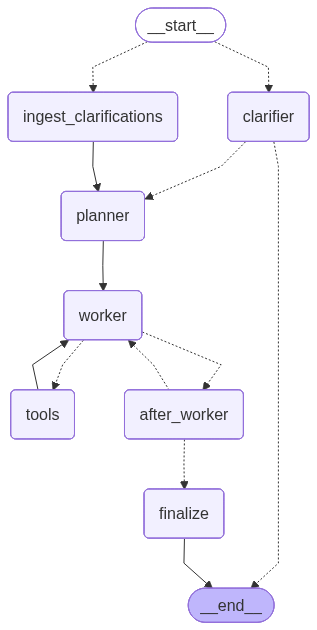

In [9]:
display(Image(graph.get_graph().draw_mermaid_png()))

## Graph execution

- Use `configurable.thread_id` to continue a conversation **across runs** (username, UUID, etc.).
- On the first turn after clarifying questions, the checkpoint still has `awaiting_clarification=True`, so the entry router sends the new user message through `ingest_clarifications` before planning.
- With **Playwright** tools, `nest_asyncio` + `invoke` usually works in Jupyter; if tool steps hang or error, use **`await graph.ainvoke(...)`** instead (see optional Gradio cell).

In [10]:
def make_thread_id() -> str:
    return str(uuid.uuid4())


def run_turn(
    user_text: str,
    *,
    success_criteria: str,
    thread_id: str,
    graph_app=None,
):
    """Append a user turn to a checkpointed thread.

    On a **new** thread, supply full defaults. On continuation (including the
    clarification round), only messages and success_criteria are merged so
    `awaiting_clarification` and other fields are not reset by mistake.
    """
    app = graph_app or graph
    config = {"configurable": {"thread_id": thread_id}}
    update: Dict[str, Any] = {
        "messages": [HumanMessage(content=user_text)],
        "success_criteria": success_criteria,
    }
    snap = app.get_state(config)
    vals = snap.values or {}
    if not vals:
        update.update(
            {
                "clarifications": {},
                "task_plan": [],
                "results": [],
                "conversation_history": [],
                "current_task_index": 0,
                "awaiting_clarification": False,
                "final_response": None,
            }
        )
    out = app.invoke(update, config=config)
    return out


# Example: single-shot run (set OPENAI_API_KEY in your environment)
# thread_id = make_thread_id()
# result = run_turn(
#     "Compute (19*2)+3 and explain stub facts about LangGraph",
#     success_criteria="Answer is correct and mentions LangGraph briefly.",
#     thread_id=thread_id,
# )
# print(result["messages"][-1].content)

### Optional: Gradio UI with session `thread_id`

In [14]:
import gradio as gr


async def process_message(message, success_criteria, history, thread_id):
    config = {"configurable": {"thread_id": thread_id}}
    criteria = success_criteria or "Be helpful and accurate."
    update: Dict[str, Any] = {
        "messages": [HumanMessage(content=message)],
        "success_criteria": criteria,
    }
    snap = graph.get_state(config)
    if not (snap.values or {}):
        update.update(
            {
                "clarifications": {},
                "task_plan": [],
                "results": [],
                "conversation_history": [],
                "current_task_index": 0,
                "awaiting_clarification": False,
                "final_response": None,
            }
        )
    result = await graph.ainvoke(update, config=config)
    reply = result["messages"][-1].content
    user = {"role": "user", "content": message}
    bot = {"role": "assistant", "content": reply}
    return history + [user, bot], ""


async def reset_session():
    return [], make_thread_id()


with gr.Blocks() as demo:
    gr.Markdown(f"## Multi-agent Sidekick")
    tid = gr.State(make_thread_id())
    chat = gr.Chatbot(type="messages")
    msg = gr.Textbox(placeholder="Your request")
    crit = gr.Textbox(placeholder="Success criteria")
    with gr.Row():
        go = gr.Button("Go")
        rst = gr.Button("New session")
    go.click(process_message, [msg, crit, chat, tid], [chat, msg])
    rst.click(reset_session, [], [chat, tid])

demo.launch()

* Running on local URL:  http://127.0.0.1:7869
* To create a public link, set `share=True` in `launch()`.


---

### Design notes

- **Clarifier pause**: ambiguous flows end after asking questions so the user can answer; the next invoke with the same `thread_id` resumes via `ingest_clarifications` → `planner`.
- **Worker / tools**: `worker` ⇄ `tools` mirrors the prebuilt *agent loop* pattern; `after_worker` advances the index and either schedules another task or `finalize`.
- **Playwright**: same setup as **4_lab4**; for async-heavy runs prefer `await graph.ainvoke(...)` (e.g. Gradio) in addition to `nest_asyncio` in Jupyter.
- **conversation_history** is updated incrementally for easy export or downstream memory; `messages` remains the canonical LangChain transcript for the LLM.